# Chaîne « cohérence déclaration ↔ photos », au niveau annonce

## Pourquoi ce recadrage

Le carnet 01 avait établi qu'un binaire entraîné sur photos d'annonce atteint 0,689 de précision
moyenne (0,855 d'aire ROC en 384 px sur détourage, fiche 0004). Au meilleur seuil : précision 0,61,
rappel 0,65 — soit **quatre alertes fausses sur dix**. Trop faible pour affirmer « cette voiture est
abîmée ».

Deux constats ont conduit à changer la promesse plutôt que le modèle.

**Le désordre des photos d'annonce, chiffré** : 27 % des photos jugées non exploitables à
l'annotation (intérieur, document, montage, capture d'écran, flou), 19 % déjà écartées faute de
véhicule visible. Sur un second lot exigeant de la tôle de carrosserie, **49 %** des photos n'en
contenaient aucune. Environ quatre photos sur dix ne portent aucune information sur l'état.

**Le décalage de granularité, mesuré en fiche 0003** : l'état déclaré est vrai au niveau de
l'annonce et faux au niveau de trois photos sur quatre.

D'où la promesse retenue : OscarIA ne dit pas « cette voiture est abîmée » mais **« les photos de
cette annonce ne soutiennent pas l'état déclaré »**. Barre à la hauteur de ce qui est mesuré, et
cohérente avec le positionnement de tiers neutre — on vérifie une déclaration, on ne juge pas un
véhicule.

## La chaîne

```
photos de l'annonce
   → tri des vues        (écarte intérieurs, documents, captures, photos ratées)
   → détourage véhicule  (detect.py, Faster R-CNN COCO en inférence pure)
   → binaire d'état      (384 px sur détourage, configuration gagnante fiche 0004)
   → agrégation          (score d'annonce)
   → comparaison à l'état déclaré
```

Rejouable par `python dl/src/experiences_annonce.py {tri|preparer|evaluer}`.

In [1]:
import sys
sys.path.insert(0, "../../src")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

import annonce
import experiences_annonce as xa

ANNOT, LOT = xa.ANNOT, xa.LOT
man = pd.read_csv(LOT / "probas_photos.csv", dtype={"ad_id": str})
print(f"{man.ad_id.nunique()} annonces, {len(man)} photos "
      f"({man.groupby('classe_declaree').ad_id.nunique().to_dict()})")
print(f"photos par annonce : {len(man)/man.ad_id.nunique():.1f} | "
      f"véhicule détecté : {man.vehicule.mean()*100:.0f} %")

600 annonces, 1813 photos ({'abime': 300, 'intact': 300})
photos par annonce : 3.0 | véhicule détecté : 96 %


## 1. Tri des vues — la brique qui traite le désordre

Étiquettes : **aucune annotation nouvelle**. Le verdict `jeter` (177 photos) contre les verdicts
`intact` / `abime` (471) du lot d'annotation.

Entrée à **224 px** et non 384 : reconnaître un document ou un habitacle est une décision globale
sur l'image, pas une affaire de détail fin. Le réglage gagnant de la détection de dégât n'a pas été
transposé sans le retester — ce serait l'erreur classique.

Compromis **asymétrique, décidé et écrit dans le code** : laisser passer une photo inexploitable
pollue le score de l'annonce entière, tandis qu'écarter à tort une bonne photo ne coûte presque
rien puisqu'une annonce en compte plusieurs. Le seuil vise donc un rappel de 0,80 sur la classe
« à jeter ».

,valeur
aire ROC,0.972
précision moyenne,0.961
prévalence (plancher),0.273
seuil à rappel ≥ 0.8,0.986
précision à ce seuil,1.000
rappel à ce seuil,0.819
part de photos écartées,0.224


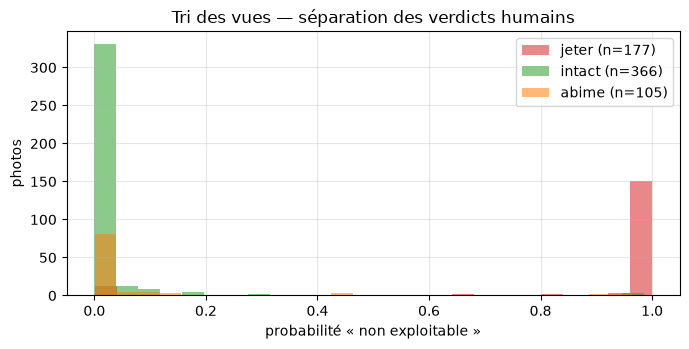

In [2]:
tri = pd.read_csv(ANNOT / "tri_vues_resultats.csv")
display(tri.T.rename(columns={0: "valeur"}))

p_tri = pd.read_csv(ANNOT / "probas_tri_vues.csv")
fig, ax = plt.subplots(figsize=(7, 3.6))
for verdict, couleur in (("jeter", "tab:red"), ("intact", "tab:green"), ("abime", "tab:orange")):
    ax.hist(p_tri.loc[p_tri.verdict == verdict, "proba_jeter"], bins=25, alpha=.55,
            label=f"{verdict} (n={(p_tri.verdict == verdict).sum()})", color=couleur)
ax.set(xlabel="probabilité « non exploitable »", ylabel="photos",
       title="Tri des vues — séparation des verdicts humains")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

**Aire ROC 0,972, précision moyenne 0,961** contre un plancher de 0,273. Les cinq blocs vont de
0,951 à 0,994 : c'est stable, pas un découpage chanceux. Au seuil retenu, **précision 1,00 pour un
rappel de 0,82** — sur les photos écartées, aucune n'était exploitable ; il en rate 18 %, mais n'en
jette jamais une bonne.

Contraste instructif avec la détection de dégât : même architecture, mêmes photos, même protocole,
**0,961 ici contre 0,689 là-bas**. La différence n'est pas le modèle mais la difficulté de la
question. « Document ou voiture ? » est une décision massive, visible à 224 px ; « cette aile est-elle
cabossée ? » tient dans quelques dizaines de pixels d'une photo de 600 px de large. **Le désordre
était plus facile à traiter que le problème qu'il masquait.**

Le modèle a ensuite servi à filtrer une file d'annotation en cours : sur 132 photos déjà triées à
la main, il prédit « aucune case de tôle utilisable » avec une aire ROC de 0,882, écarte 34 % des
photos dont **98 % étaient effectivement inutilisables**, pour **une seule** photo utile perdue. Une
brique qui rend du temps au lieu d'en consommer.

## 2. Le lot d'évaluation par annonce

600 annonces, 300 déclarées `damaged` et 300 déclarées `undamaged` / `excellent_condition`,
toutes leurs photos (plafonnées à 5), soit 1 813 photos.

**`not_drivable` est exclu** : 73 % de ses photos montrent une carrosserie intacte, « non roulant »
désignant le plus souvent un moteur ou une boîte hors service. L'étiquette est juste, elle ne parle
pas de ce que le modèle regarde.

**Anti-fuite** : seules les 800 annonces du lot d'annotation sont exclues — celles qui ont entraîné
le binaire évalué ici. Les lots de négatifs CarDD ne le sont pas : ils ont alimenté un **autre**
modèle. Une première tentative avait tout exclu et vidé le vivier (9 annonces intactes disponibles
au lieu de 300). L'anti-fuite se raisonne par **couple modèle-évaluation**, pas par « donnée déjà
touchée ».

In [3]:
resume = man.groupby("classe_declaree").agg(
    annonces=("ad_id", "nunique"), photos=("fichier", "size"),
    vehicule_detecte=("vehicule", "mean"),
    ecartees_par_le_tri=("proba_jeter", lambda s: (s >= .5).mean())).round(3)
display(resume)
print(f"photos écartées par le tri, toutes classes : {(man.proba_jeter >= .5).mean()*100:.0f} %")

,annonces,photos,vehicule_detecte,ecartees_par_le_tri
classe_declaree,,,,
abime,300,862,0.947,0.216
intact,300,951,0.975,0.290


photos écartées par le tri, toutes classes : 25 %


## 3. Agrégation — du score par photo au score par annonce

Trois règles, et le choix entre elles est une **décision produit**, pas technique :

- **max** : une seule photo suffit à alerter. Sensible, mais alarmiste — une fausse alerte coûte de
  l'argent au vendeur en négociation.
- **moyenne** : dilue le seul cliché qui montre le dégât, précisément celui qui compte.
- **moyenne des deux meilleures** : exige deux photos concordantes.

Les deux effets — agrégation et filtrage — sont mesurés **séparément** : branchés ensemble, un gain
global ne dirait pas lequel des deux l'a produit.

In [4]:
res = pd.read_csv(LOT / "resultats_agregation.csv")
display(res)

base = res.loc[res["niveau"].str.startswith("photo"), "aire ROC"].iloc[0]
sans = res.query("`filtre tri` == 'non' and règle == 'moyenne'")["aire ROC"].iloc[0]
avec = res.query("`filtre tri` == 'oui' and règle == 'moyenne'")["aire ROC"].iloc[0]
print(f"photo → annonce (moyenne)      : {base:.3f} → {sans:.3f}  ({sans-base:+.3f})")
print(f"annonce → + filtre du tri      : {sans:.3f} → {avec:.3f}  ({avec-sans:+.3f})")

,niveau,filtre tri,règle,annonces,aire ROC,précision moyenne
0,photo (sans agrégation),non,—,NaN,0.729,0.722
1,annonce,non,max,600.0,0.770,0.775
2,annonce,non,moyenne,600.0,0.793,0.799
3,annonce,non,moyenne_top2,600.0,0.781,0.791
4,annonce,oui,max,593.0,0.799,0.808
5,annonce,oui,moyenne,593.0,0.807,0.807
6,annonce,oui,moyenne_top2,593.0,0.806,0.810


photo → annonce (moyenne)      : 0.729 → 0.793  (+0.064)
annonce → + filtre du tri      : 0.793 → 0.807  (+0.014)


**L'agrégation apporte l'essentiel** (+0,064), le filtrage un complément gratuit (+0,014).

**La moyenne bat le maximum, et c'est contre-intuitif.** L'intuition dit : une seule photo montre le
dégât, prenons le maximum. La mesure dit l'inverse — le maximum amplifie aussi le **bruit**, une
seule fausse alerte suffisant à condamner l'annonce. À 0,61 de précision par photo, réduire le bruit
rapporte plus que capter le signal rare.

**Avertissement de comparabilité.** Ce 0,807 n'est pas comparable au 0,855 de la fiche 0004 : là-bas
on prédisait le verdict d'un humain sur une photo, avec 22 % de prévalence ; ici la déclaration d'un
vendeur sur une annonce entière, avec 50 % de prévalence. Deux questions, deux planchers, deux
populations. Les aligner dans un tableau de progression serait malhonnête.

## 4. Le point de fonctionnement produit

Ce que le vendeur verra dépend du seuil, et ce choix est un arbitrage explicite entre alerter trop
et ne rien voir.

,seuil,précision,rappel,part des annonces signalées
0,0.344,0.903,0.345,19.1 %
1,0.202,0.851,0.483,28.3 %
2,0.085,0.801,0.625,39.0 %
3,0.048,0.750,0.720,47.9 %


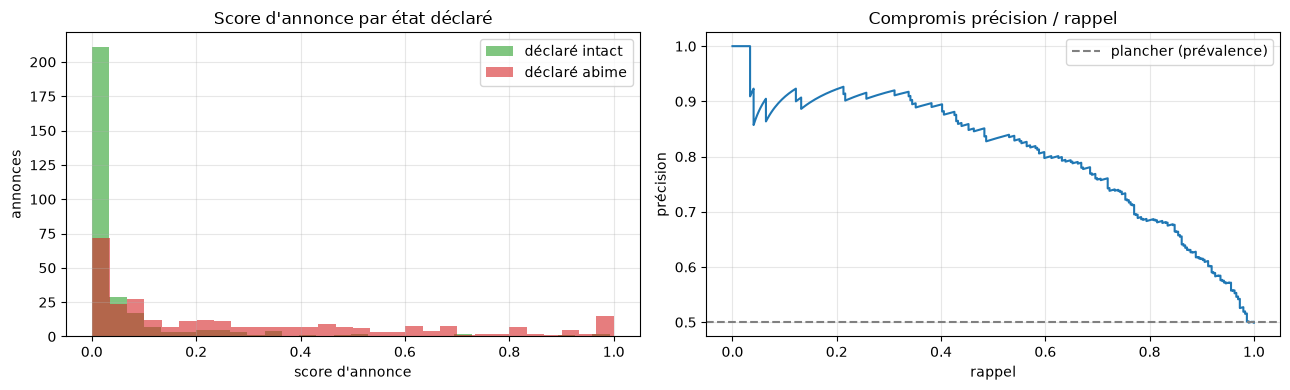

In [5]:
sous = man[man.proba_jeter < 0.5]
sc = annonce.agreger(sous, "moyenne").set_index("ad_id")["score_annonce"]
verite = man.groupby("ad_id").classe_declaree.first()
y = (verite.loc[sc.index] == "abime").astype(int).values

p, r, seuils = precision_recall_curve(y, sc.values)
lignes = []
for cible in (0.90, 0.85, 0.80, 0.75):
    ok = np.where(p[:-1] >= cible)[0]
    if len(ok):
        k = int(ok[np.argmax(r[:-1][ok])])
        lignes.append({"seuil": round(float(seuils[k]), 3), "précision": round(float(p[k]), 3),
                       "rappel": round(float(r[k]), 3),
                       "part des annonces signalées": f"{(sc.values >= seuils[k]).mean()*100:.1f} %"})
display(pd.DataFrame(lignes))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for classe, couleur in (("intact", "tab:green"), ("abime", "tab:red")):
    axes[0].hist(sc.values[verite.loc[sc.index].values == classe], bins=30, alpha=.6,
                 label=f"déclaré {classe}", color=couleur)
axes[0].set(xlabel="score d'annonce", ylabel="annonces",
            title="Score d'annonce par état déclaré"); axes[0].legend(); axes[0].grid(alpha=.3)
axes[1].plot(r, p); axes[1].axhline(0.5, ls="--", color="gray", label="plancher (prévalence)")
axes[1].set(xlabel="rappel", ylabel="précision", title="Compromis précision / rappel")
axes[1].legend(); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

Au seuil le plus prudent : **OscarIA signale une annonce sur cinq, et neuf fois sur dix la
déclaration est effectivement contredite par les photos.** Il rate deux tiers des cas — mais il ne
crie pas au loup, ce qui est le comportement attendu d'un tiers neutre.

## Limites — à rappeler à chaque citation de ces chiffres

- **L'évaluation compare le modèle à l'état DÉCLARÉ, pas à une vérité terrain.** Une annonce
  `damaged` dont le dégât est purement mécanique compte comme un échec alors que le modèle a raison.
  Cohérent avec la promesse (« les photos soutiennent-elles la déclaration ? »), mais interdit de
  parler de détection de dégât.
- **Lot équilibré 50/50 par construction.** La prévalence réelle des annonces avec dégât visible est
  inconnue ; en population réelle, la précision au même seuil serait différente.
- **7 annonces sur 600 perdues** par le filtre (plus aucune photo exploitable). En production, ce
  cas doit renvoyer « photos insuffisantes pour se prononcer », jamais un score par défaut.
- **Le binaire d'état a été entraîné sur 471 photos annotées par un seul annotateur non expert**,
  sans accord inter-annotateurs.
- **Un seul segment** : annonces de particuliers, une plateforme, collecte de juillet 2026.
- **Probabilités non calibrées** : la perte est pondérée pour compenser le déséquilibre, ce qui
  décale mécaniquement les sorties. Afficher « 0,34 » comme un risque de 34 % serait faux — la
  calibration reste à faire avant tout affichage.
- **RGPD** : plaques et visages présents dans les photos, masquage requis avant tout livrable.